In [20]:
from helpers import load_config
import os
import h5py
config_path = os.path.abspath("pyloco_config.py")
load_config(config_path=config_path)
from pyloco import pyloco, remove_bad_bpms, plot_data
import numpy as np
import at


ring = at.load_lattice('p3_low_beta.mat')
elements_ind = at.get_refpts(ring, "*")
_, _, twiss = at.get_optics(ring, elements_ind)
# ============================================================================== #
#                Prepare quadrupoles,skews, correctors, bpms, cavity indices
# ============================================================================== #

quad_indices = np.load('./data/quad_ind.npy')
skew_ord = np.load('./data/skew_ind.npy')

data = np.load('./data/CMstep.npz')
CMstep = [data['hor'], data['ver']]

def load_names(filename):
    with open(filename, 'r') as file:
        names = [line.strip() for line in file.readlines()]
    return names

HCM_names = load_names("./data/HCM_names.txt")
VCM_names = load_names("./data/VCM_names.txt")
BPMs_names = load_names("./data/BPM_names.txt")

cor_ind_x = []
for i, elem in enumerate(ring):
    if getattr(elem, 'CommonName', None) in HCM_names:
        cor_ind_x.append(i)

cor_ind_y = []
for i, elem in enumerate(ring):
    if getattr(elem, 'CommonName', None) in VCM_names:
        cor_ind_y.append(i)

used_bpm = []
for i, elem in enumerate(ring):
    if getattr(elem, 'CommonName', None) in BPMs_names:
        used_bpm.append(i)

#used_bpm = at.get_refpts(ring, at.elements.Monitor)

sorted_cor_ind_x = np.sort(cor_ind_x)
sorted_cor_ind_y = np.sort(cor_ind_y)
Corords = [sorted_cor_ind_x, sorted_cor_ind_y]
CAVords = at.get_refpts(ring, at.elements.RFCavity)

# --- Load Measurments ---
with h5py.File("measured_orm_loco.h5", "r") as f:
    measured_orm = np.array(f["response_matrix"]) # in meter [BPMs X Cor]

with h5py.File("measured_dispersion_loco.h5", "r") as f:  # in meter
    measured_eta_x_ = np.array(f["measured_eta_x"])
    measured_eta_y_ = np.array(f["measured_eta_y"])
    attrs_eta = dict(f.attrs)

with h5py.File("measured_BPM_noise_loco.h5", "r") as f:  # in meter
    Noise_BPMx = np.array(f["Noise_BPMx"])
    Noise_BPMy = np.array(f["Noise_BPMy"])
    attrs_noise = dict(f.attrs)


# ============================================================================== #
#               Remove bad BPMs from measurment data
# ============================================================================== #

bad_bpm_ind = [1973, 5639, 5681, 5825, 6011, 6087, 6197, 6297, 6311, 7641]
bad_bpm_positions = np.array([24, 104, 108, 111, 123, 138, 144, 153, 161,162, 243])
Noise_BPMx_cleaned = np.delete(Noise_BPMx, bad_bpm_positions)
Noise_BPMy_cleaned = np.delete(Noise_BPMy, bad_bpm_positions)
sigma_w = np.concatenate((Noise_BPMx_cleaned, Noise_BPMy_cleaned))[:, np.newaxis]  # Note: weight matrix shape for pyloco
used_bpms_ords = np.delete(used_bpm, bad_bpm_positions)


measured_eta_x = np.delete(measured_eta_x_, bad_bpm_positions)
measured_eta_y = np.delete(measured_eta_y_, bad_bpm_positions)


measured_orm , removed = remove_bad_bpms(measured_orm,
                                     bad_bpm_positions,
                                     total_bpms=len(used_bpm),
                                     axis=0,
                                     input_type="positions")


==== Iteration 1/8 – LM ====
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/PETRAIII/output/quad_jacobian_logs.txt'
Initial Chi²: 2.4559e+04


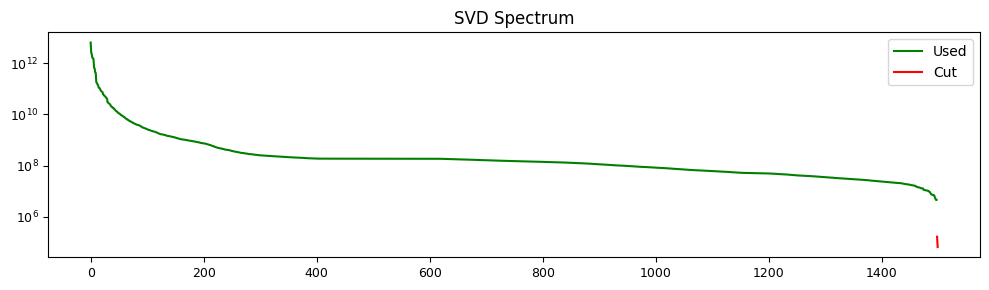

  LM inner 1: chi² 6.5528e+02 (previous 2.4559e+04), λ=0.001
Chi² after correction: 6.5528e+02

==== Iteration 2/8 – LM ====
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/PETRAIII/output/quad_jacobian_logs.txt'
Initial Chi²: 6.5528e+02


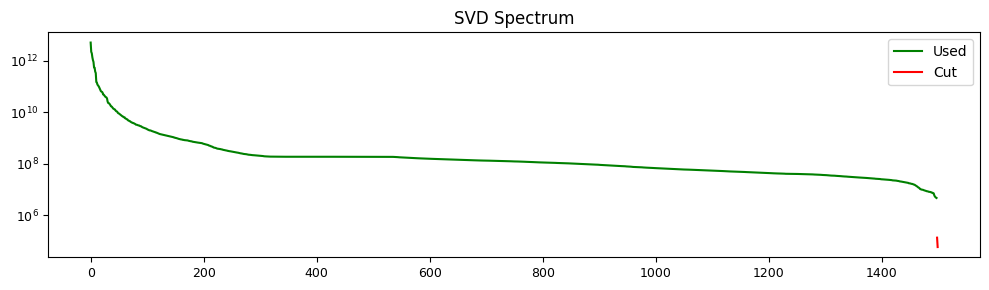

  LM inner 1: chi² 7.2323e+00 (previous 6.5528e+02), λ=0.001
Chi² after correction: 7.2323e+00

==== Iteration 3/8 – LM ====
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/PETRAIII/output/quad_jacobian_logs.txt'
Initial Chi²: 7.2323e+00


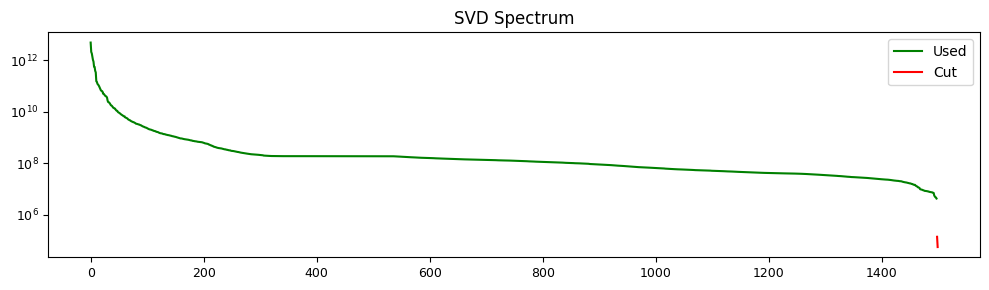

  LM inner 1: chi² 5.3295e+00 (previous 7.2323e+00), λ=0.001
Chi² after correction: 5.3295e+00

==== Iteration 4/8 – LM ====
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/PETRAIII/output/quad_jacobian_logs.txt'
Initial Chi²: 5.3283e+00


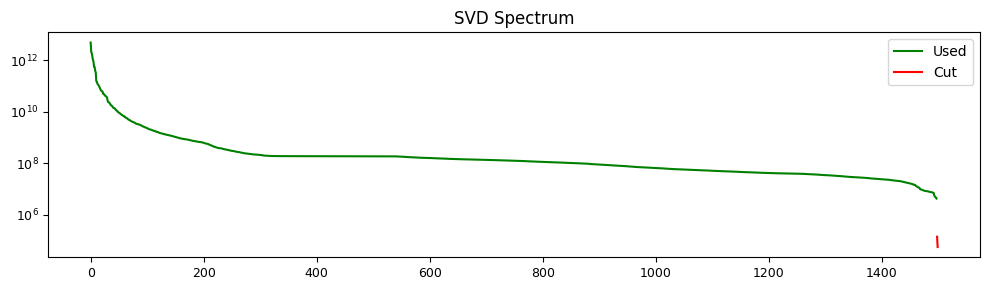

  LM inner 1: chi² 5.1940e+00 (previous 5.3283e+00), λ=0.001
Chi² after correction: 5.1940e+00

==== Iteration 5/8 – LM ====
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/PETRAIII/output/quad_jacobian_logs.txt'
Initial Chi²: 5.1940e+00


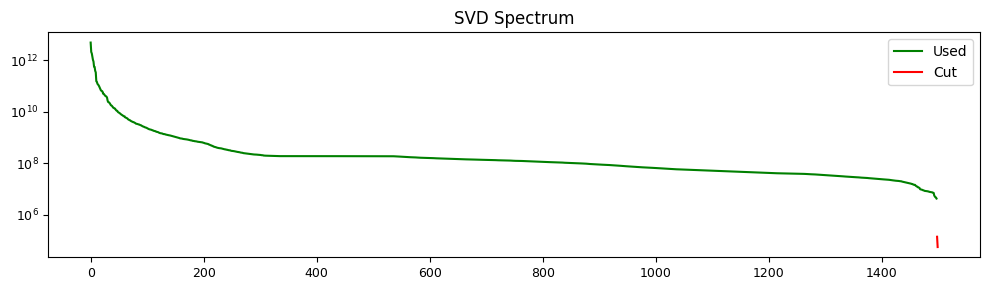

  LM inner 1: chi² 5.1525e+00 (previous 5.1940e+00), λ=0.001
Chi² after correction: 5.1525e+00

==== Iteration 6/8 – LM ====
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/PETRAIII/output/quad_jacobian_logs.txt'
Initial Chi²: 5.1525e+00


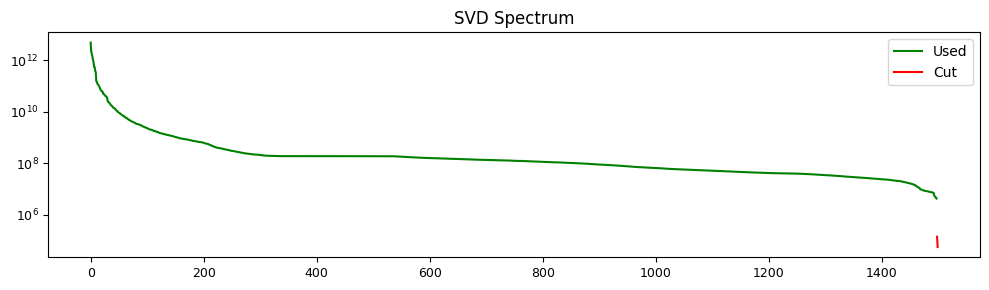

  LM inner 1: chi² 5.1327e+00 (previous 5.1525e+00), λ=0.001
Chi² after correction: 5.1327e+00

==== Iteration 7/8 – LM ====
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/PETRAIII/output/quad_jacobian_logs.txt'
Initial Chi²: 5.1327e+00


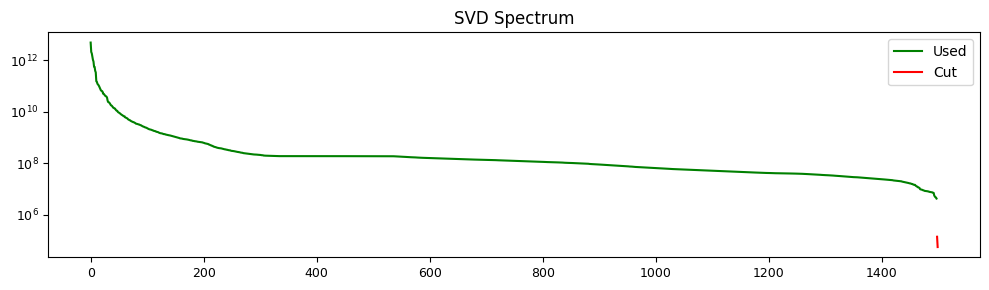

  LM inner 1: chi² 5.1205e+00 (previous 5.1327e+00), λ=0.001
Chi² after correction: 5.1205e+00

==== Iteration 8/8 – LM ====
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/PETRAIII/output/quad_jacobian_logs.txt'
Initial Chi²: 5.1205e+00


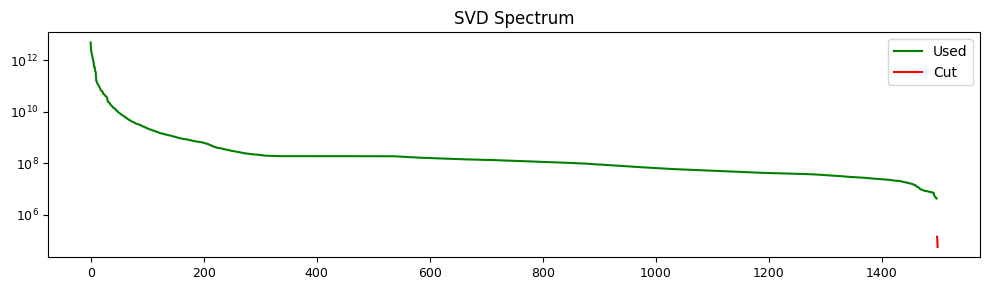

  LM inner 1: chi² 5.1119e+00 (previous 5.1205e+00), λ=0.001
Chi² after correction: 5.1119e+00
LOCO LM completed! :).


In [21]:
import numpy as np
from pyloco_config import FitInitConfig, fixed_parameters

fit_cfg = FitInitConfig()

# --- define arguments ---
nIter      = 8
nHorCOR    = len(Corords[0])
nVerCOR    = len(Corords[1])
nHBPM      = 235
nVBPM      = 235
cut_       = 397

fit_list   = [
    "quads",
    "hbpm_gain",
    "vbpm_gain",
    "hcor_cal",
    "vcor_cal",
    "HCMEnergyShift",
]
svd_method = "threshold"
svd_thresh = 1e-7

# --- run LOCO correction ---
fit_results, fit_dict,  ring = pyloco(
    ring,

    # --- general control ---
    algorithm="lm",
    nIter=nIter,

    # --- indices & number of elements ---
    used_bpms_ords=used_bpms_ords,
    used_cor_ords=Corords,
    quads_ords=quad_indices,
    skew_ords=None,
    CAVords=CAVords,
    nHBPM=nHBPM,
    nVBPM=nVBPM,
    nHorCOR=nHorCOR,
    nVerCOR=nVerCOR,
    quads_tilt_ind=None,
    inetial_fit_parameters=None,


    # --- measurement data ---
    orm_measured=measured_orm,
    weights=sigma_w,
    includeDispersion=False,
    measured_eta_x=measured_eta_x,
    measured_eta_y=measured_eta_y,
    hor_dispersion_weight=1.0,
    ver_dispersion_weight=1.0,

    # --- correctors kicks & RF ---
    CMstep=CMstep,
    rfStep=fixed_parameters.rfstep,
    Frequency = fixed_parameters.Frequency,

    # --- features ---
    fit_list=fit_list,
    individuals=True,
    remove_coupling_=True,

    # --- outliers & normalization ---
    outlier_rejection=True,
    sigma_outlier=10,
    apply_normalization=True,
    normalization_mode="component",

    # --- SVD selection ---
    svd_selection_method=svd_method,
    svd_threshold=svd_thresh,
    cut_=cut_,
    show_svd_plot=True,

    # --- LM options ---
    nLMIter=10,
    Starting_Lambda=1e-3,
    max_lm_lambda=15,
    scaled=True,

    # --- more options ---
    plot_fit_parameters=False,
    auto_correct_delta=True,
    fixedpathlength=False,
    fit_cfg=fit_cfg,
)

# --- save results ---
np.save("./output/loco_lm_fit_results_iterations.npy", fit_results)


Lattice tune after loco : [0.12029783 0.30368832]


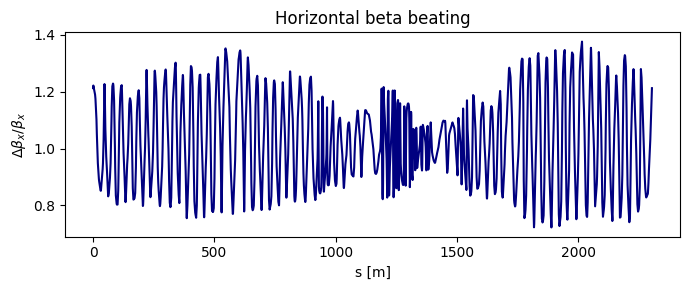

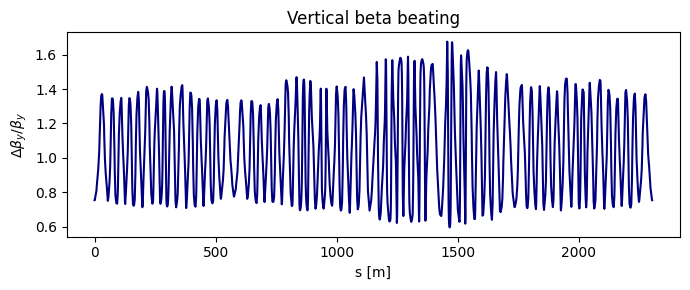

In [22]:
print('Lattice tune after loco :' , at.get_tune(ring))
_, _, twiss_err = at.get_optics(ring, elements_ind)
s_pos = twiss_err.s_pos
bx = (twiss_err.beta[:, 0]) / twiss.beta[:, 0]
by = (twiss_err.beta[:, 1]) / twiss.beta[:, 1]
plot_data(s_pos, bx, "s [m]", r"$\Delta\beta_x / \beta_x$ ", "Horizontal beta beating")
plot_data(s_pos, by, "s [m]", r"$\Delta\beta_y / \beta_y$ ", "Vertical beta beating")

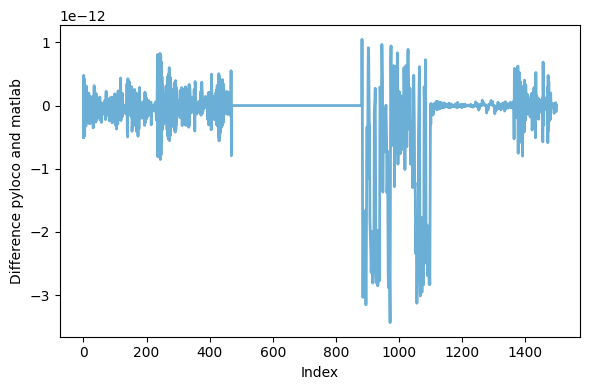

In [23]:
import matplotlib.pyplot as plt
fit_results_matlab = np.load('./data/matlab_fit_8iter.npy')
rel_diff = (fit_results_matlab - fit_results[len(fit_results)-1])
plt.figure(figsize=(6, 4))
plt.plot(rel_diff, color="#6baed6", lw=2)
plt.xlabel("Index")
plt.ylabel("Difference pyloco and matlab")
plt.tight_layout()
plt.show()